**Experiment 6**

In [1]:
# Cell 1 — Install dependencies
!pip -q install opacus==1.4.0 tqdm pandas matplotlib torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 20.0 MB/s eta 0:00:00


In [2]:
# Cell 2 — Imports + reproducibility
import os, math, random
from copy import deepcopy
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt



# Wider alpha grid => avoids "optimal order is the largest alpha" warning
RDP_ALPHAS = (
    [1.01, 1.05] +
    [1.1 + 0.1*i for i in range(0, 90)] +      # 1.1..10.0
    list(range(11, 64)) + [64, 128, 256, 512]
)

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


In [3]:
# Cell 3 — Dataset: Fashion-MNIST + loaders
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.2860,), (0.3530,))
])

train_ds = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

test_loader = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
print("train:", len(train_ds), "test:", len(test_ds))


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 177kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.50MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.3MB/s]

train: 60000 test: 10000


In [4]:
# Cell 4 — PUBLIC set + IID clients (DISJOINT, recommended for paper)
# Public points removed from private client datasets.

NUM_CLASSES = 10
PUBLIC_PER_CLASS = 20      # 200 public points (try 30 => 300)
SAMPLES_PER_CLIENT = 10
CLIENTS_PER_ROUND = 100

def extract_public_per_class(dataset, per_class=20, seed=0):
    rng = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    public_idx = []
    for k in range(NUM_CLASSES):
        cls_idx = np.where(targets == k)[0]
        rng.shuffle(cls_idx)
        public_idx.extend(cls_idx[:per_class].tolist())
    return sorted(public_idx)

public_idx = extract_public_per_class(train_ds, per_class=PUBLIC_PER_CLASS, seed=0)

all_train_idx = np.arange(len(train_ds))
mask = np.ones(len(train_ds), dtype=bool)
mask[np.array(public_idx)] = False
avail_idx = all_train_idx[mask]  # private-only indices

NUM_CLIENTS = len(avail_idx) // SAMPLES_PER_CLIENT
private_needed = NUM_CLIENTS * SAMPLES_PER_CLIENT
avail_idx = avail_idx[:private_needed]

def build_iid_clients_from_indices(indices, num_clients, samples_per_client, seed=0):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(indices)
    return [perm[i*samples_per_client:(i+1)*samples_per_client].tolist()
            for i in range(num_clients)]

clients = build_iid_clients_from_indices(avail_idx, NUM_CLIENTS, SAMPLES_PER_CLIENT, seed=0)

print("public samples:", len(public_idx), f"(per_class={PUBLIC_PER_CLASS})")
print("private samples:", len(avail_idx))
print("NUM_CLIENTS:", NUM_CLIENTS, "| samples/client:", SAMPLES_PER_CLIENT, "| clients/round:", CLIENTS_PER_ROUND)
print("q =", CLIENTS_PER_ROUND / NUM_CLIENTS)

public samples: 200 (per_class=20)
private samples: 59800
NUM_CLIENTS: 5980 | samples/client: 10 | clients/round: 100
q = 0.016722408026755852


In [5]:
# Cell 6 — Model + evaluation
class FMNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)  # 14x14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)  # 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total


In [6]:
# Cell 7 — Tensor-list + flatten helpers
def model_param_list(model):
    return [p for p in model.parameters() if p.requires_grad]

@torch.no_grad()
def zero_like_params(model):
    return [torch.zeros_like(p.data) for p in model_param_list(model)]

@torch.no_grad()
def add_update_(model, update_list, scale=1.0):
    for p, u in zip(model_param_list(model), update_list):
        p.data.add_(u, alpha=scale)

@torch.no_grad()
def add_scaled_list_(dst, src, alpha):
    for d, s in zip(dst, src):
        d.add_(s, alpha=float(alpha))

@torch.no_grad()
def norm_sq_list(tlist):
    s = None
    for t in tlist:
        v = (t*t).sum()
        s = v if s is None else s + v
    return s + 1e-12

@torch.no_grad()
def l2_norm_list(tlist):
    return torch.sqrt(norm_sq_list(tlist))

def sub_list(a, b):
    return [x - y for x, y in zip(a, b)]

@torch.no_grad()
def dot_list(a_list, b_list):
    s = None
    for a, b in zip(a_list, b_list):
        v = (a*b).sum()
        s = v if s is None else s + v
    return s

@torch.no_grad()
def flatten_list(tlist):
    return torch.cat([t.reshape(-1) for t in tlist])

@torch.no_grad()
def unflatten_like(vec, template_list):
    out = []
    idx = 0
    for t in template_list:
        n = t.numel()
        out.append(vec[idx:idx+n].view_as(t))
        idx += n
    return out


In [7]:
# Cell 8 — Local client update (SGD) returns delta = (local - global)
loss_fn = nn.CrossEntropyLoss()

def client_update(global_model, client_indices, lr, momentum, local_epochs=1, batch_size=10):
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(Subset(train_ds, client_indices),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(local_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta.append((lp.data - gp.data).detach())
    return delta


In [8]:
# Cell 9 — DP accounting (RDP) + sigma search (Opacus-version-proof)
# Purpose: compute epsilon for given noise multiplier(s) and binary-search sigma.

from opacus.accountants.analysis import rdp as rdp_analysis

def _compute_rdp(q, noise_multiplier, steps, orders):
    # Some versions accept kwargs, others positional; support both.
    try:
        return rdp_analysis.compute_rdp(q=q, noise_multiplier=noise_multiplier, steps=steps, orders=orders)
    except TypeError:
        return rdp_analysis.compute_rdp(q, noise_multiplier, steps, orders)

def _get_eps(orders, rdp, delta):
    try:
        eps, _ = rdp_analysis.get_privacy_spent(orders=orders, rdp=rdp, delta=delta)
    except TypeError:
        eps, _ = rdp_analysis.get_privacy_spent(orders, rdp, delta)
    return float(eps)

def epsilon_from_sigma_single(sigma, q, steps, delta):
    rdp = _compute_rdp(q, float(sigma), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp, delta)

def epsilon_from_sigma_two(sig_sel, sig_rel, q, steps, delta):
    rdp1 = _compute_rdp(q, float(sig_sel), int(steps), RDP_ALPHAS)
    rdp2 = _compute_rdp(q, float(sig_rel), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp1 + rdp2, delta)

def find_sigma_for_target_eps_single(target_eps, q, steps, delta, iters=50):
    lo, hi = 1e-4, 1.0
    while epsilon_from_sigma_single(hi, q, steps, delta) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound. Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5*(lo+hi)
        if epsilon_from_sigma_single(mid, q, steps, delta) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)

def find_sigma_rel_for_target_eps_two(target_eps, q, steps, delta, sel_factor=2.0, iters=50):
    # sig_sel = sel_factor * sig_rel
    lo, hi = 1e-4, 1.0
    def E(sig_rel):
        return epsilon_from_sigma_two(sel_factor*sig_rel, sig_rel, q, steps, delta)

    while E(hi) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound (two). Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5*(lo+hi)
        if E(mid) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)


In [9]:
# Cell 10 — ALIE attack helpers (constant-z, consistent across f)
# Purpose: ALIE strength does NOT change with Byzantine fraction.

@torch.no_grad()
def alie_attack_from_honest_constz(honest_updates, byz_count, z=2.0, direction=-1.0):
    """
    Returns byz_count malicious updates where:
        mal = mu + direction * z * std   (coordinate-wise)
    z is constant (same for all f).
    """
    if byz_count <= 0:
        return []
    if len(honest_updates) == 0:
        raise ValueError("No honest updates to build ALIE.")

    P = len(honest_updates[0])
    mal = []
    for j in range(P):
        stacked = torch.stack([u[j] for u in honest_updates], dim=0)
        mu = stacked.mean(dim=0)
        sd = stacked.std(dim=0, unbiased=False) + 1e-12
        mal.append(mu + float(direction) * float(z) * sd)

    mal = [t.detach() for t in mal]
    return [[t.clone() for t in mal] for _ in range(byz_count)]


In [10]:
# Cell 11 — DP-FedAvg robust under ALIE (constant-z)
def train_dp_fedavg_robust(seed, eps_total, byz_frac,
                           sigma, delta=1e-5,
                           num_clients=len(clients), clients_per_round=CLIENTS_PER_ROUND,
                           rounds=30, local_epochs=10, batch_size=10,
                           lr0=0.125, lr_decay=0.99, momentum=0.5,
                           clip_C=1.0,
                           alie_direction=-1.0, alie_z=2.0):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    for t in tqdm(range(rounds), desc=f"DP-FedAvg f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b>0 else set()

        honest_updates = []
        for j, cid in enumerate(chosen):
            if j in byz_pos:
                continue
            honest_updates.append(
                client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                              local_epochs=local_epochs, batch_size=batch_size)
            )

        byz_updates = alie_attack_from_honest_constz(honest_updates, b, z=alie_z, direction=alie_direction) if b>0 else []

        sum_update = zero_like_params(model)

        for upd in honest_updates + byz_updates:
            nrm = l2_norm_list(upd).item()
            scale = min(1.0, clip_C/(nrm + 1e-12))
            add_scaled_list_(sum_update, upd, scale)

        for j in range(len(sum_update)):
            sum_update[j].add_(torch.randn_like(sum_update[j]) * (sigma * clip_C))

        avg_update = [u / clients_per_round for u in sum_update]
        add_update_(model, avg_update, scale=1.0)

    acc = evaluate(model, test_loader)
    return acc


In [11]:
# Cell 12 — AG-PTR (Experiment 6): geometry alignment ablation
# Compare:
#   (A) P_t = I                     (Euclidean clipping + isotropic DP noise)
#   (B) P_t = FedAdam-aligned diag   (clipping + DP noise shaped to Adam geometry)
#
# Server update uses FedAdam in BOTH variants. Only P_t changes.

import math
import numpy as np
import torch
from copy import deepcopy
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm

# ---- (Optional) safety checks: makes errors clearer after a disconnect ----
_required = [
    "train_ds", "public_idx", "clients", "CLIENTS_PER_ROUND",
    "FMNIST_CNN", "device",
    "seed_all", "evaluate",
    "client_update", "alie_attack_from_honest_constz",
    "model_param_list", "zero_like_params",
    "add_scaled_list_", "sub_list",
    "norm_sq_list", "dot_list",
]
_missing = [k for k in _required if k not in globals()]
if _missing:
    raise NameError(
        "You restarted/disconnected and some required earlier definitions are missing.\n"
        "Please re-run Cells 1–11 first.\n"
        f"Missing: {_missing}"
    )

# loss_fn is defined earlier in your notebook; define a fallback if not present
try:
    loss_fn
except NameError:
    import torch.nn as nn
    loss_fn = nn.CrossEntropyLoss()


# -------------------------
# Public-anchor helpers (these were missing in your error)
# -------------------------
def public_anchor_update_on_subset(global_model, subset_indices, lr, momentum,
                                   public_epochs=1, pub_batch_size=64):
    """
    One small SGD run on a PUBLIC subset, starting from global_model.
    Returns delta_pub = (public_model - global_model) as list-of-tensors.
    """
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(train_ds, subset_indices),
        batch_size=min(int(pub_batch_size), len(subset_indices)),
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(local_model.parameters(), lr=float(lr), momentum=float(momentum))

    for _ in range(int(public_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta_pub = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta_pub.append((lp.data - gp.data).detach())
    return delta_pub


def build_public_anchors(global_model, public_indices, R, lr, momentum,
                         public_epochs=1, pub_batch=20, pub_scale=0.1, seed=0):
    """
    Build R anchors from PUBLIC data:
      - sample a random public minibatch of size pub_batch
      - do a tiny SGD run (public_epochs)
      - anchor = pub_scale * delta_pub
    Returns: list length R, each element is list-of-tensors
    """
    rng = np.random.RandomState(int(seed))
    anchors = []
    for _ in range(int(R)):
        k = min(int(pub_batch), len(public_indices))
        subset = rng.choice(public_indices, size=k, replace=False).tolist()
        delta_pub = public_anchor_update_on_subset(
            global_model, subset, lr=lr, momentum=momentum,
            public_epochs=public_epochs, pub_batch_size=k
        )
        anchors.append([float(pub_scale) * d for d in delta_pub])
    return anchors


def _avg_anchor(anchor_list):
    """Average a list of anchors (each anchor is list-of-tensors)."""
    P = len(anchor_list[0])
    out = []
    for j in range(P):
        out.append(torch.stack([a[j] for a in anchor_list], dim=0).mean(dim=0).detach())
    return out


# -------------------------
# Metric helpers for geometry P_t
# -------------------------
@torch.no_grad()
def norm_sq_list_metric(tlist, P_list=None):
    """||x||_P^2 = sum_j <x_j, P_j x_j>, with diagonal P_j matching tensor shapes.
       If P_list is None, defaults to Euclidean.
    """
    if P_list is None:
        return norm_sq_list(tlist)
    s = None
    for t, w in zip(tlist, P_list):
        v = (w * (t * t)).sum()
        s = v if s is None else s + v
    return s + 1e-12


@torch.no_grad()
def l2_norm_list_metric(tlist, P_list=None):
    return torch.sqrt(norm_sq_list_metric(tlist, P_list))


@torch.no_grad()
def dot_list_metric(a_list, b_list, P_list=None):
    """<a,b>_P = sum_j <a_j, P_j b_j> (diagonal P). If None, defaults to Euclidean."""
    if P_list is None:
        return dot_list(a_list, b_list)
    s = None
    for a, b, w in zip(a_list, b_list, P_list):
        v = (w * a * b).sum()
        s = v if s is None else s + v
    return s


# -------------------------
# FedAdam server step (used in BOTH variants; DP-safe post-processing)
# -------------------------
@torch.no_grad()
def fedadam_step_(model, m_state, v_state, delta_list,
                  eta=0.1, beta1=0.9, beta2=0.99, tau=1e-9, step_idx=0):
    """
    FedAdam server update:
      m <- beta1*m + (1-beta1)*delta
      v <- beta2*v + (1-beta2)*delta^2
      eta_norm = eta * sqrt(1-beta2^(t+1)) / (1-beta1^(t+1))
      w <- w + eta_norm * m / (sqrt(v) + tau)
    """
    b1 = float(beta1); b2 = float(beta2)
    for i, d in enumerate(delta_list):
        m_state[i].mul_(b1).add_(d, alpha=(1.0 - b1))
        v_state[i].mul_(b2).addcmul_(d, d, value=(1.0 - b2))

    eta_norm = float(eta) * math.sqrt(1.0 - (b2 ** (step_idx + 1))) / (1.0 - (b1 ** (step_idx + 1)))

    for p, m, v in zip(model_param_list(model), m_state, v_state):
        p.data.add_(m / (torch.sqrt(v) + float(tau)), alpha=float(eta_norm))


# -------------------------
# AG-PTR with geometry ablation
# -------------------------
def train_ag_ptr(seed, eps_total, byz_frac,
                 sigma_sel, sigma_rel, delta=1e-5,
                 rounds=30, local_epochs=10, batch_size=10,
                 lr0=0.125, lr_decay=0.99, momentum=0.5,
                 rho=0.79, tau=60,
                 # public anchor construction
                 R_pub_avg=8, pub_batch=20, pub_scale=0.1, public_epochs=1,
                 # ALIE attack (constant-z)
                 alie_direction=-1.0, alie_z=2.0,
                 # policy
                 allow_zero=False,
                 # ---- Experiment 6 knobs ----
                 P_mode="identity",          # "identity" or "fedadam_diag"
                 # FedAdam server optimizer (used for BOTH variants)
                 adam_eta=0.1, adam_beta1=0.9, adam_beta2=0.99, adam_tau=1e-9,
                 adam_v_init=1e-6):          # warm-start v to avoid v=0 => huge precond in round 0

    seed_all(int(seed))
    rng = np.random.RandomState(int(seed))

    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    model = FMNIST_CNN().to(device)
    zero_anchor = zero_like_params(model)

    # FedAdam state (server)
    m_state = zero_like_params(model)
    v_state = [torch.ones_like(p.data) * float(adam_v_init) for p in model_param_list(model)]
    opt_step = 0  # increments only on ACCEPTED rounds

    accept = 0

    for t in tqdm(range(int(rounds)), desc=f"AG-PTR Exp6 f={int(100*byz_frac)}% | P={P_mode}"):

        lr_t = float(lr0) * (float(lr_decay) ** int(t))
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(float(byz_frac) * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        # -------------------------
        # Geometry P_t for this round
        # -------------------------
        if P_mode == "identity":
            P_list = None
            inv_sqrtP_list = None  # isotropic noise
        elif P_mode == "fedadam_diag":
            # denom = sqrt(v) + adam_tau, precond = 1/denom
            denom_list = [(torch.sqrt(v).detach() + float(adam_tau)) for v in v_state]
            # P = precond^2 = 1/denom^2  (diagonal)
            P_list = [1.0 / (d * d) for d in denom_list]
            # To sample N(0, (sigma*rho)^2 * P^{-1}), multiply standard normal by P^{-1/2} = denom
            inv_sqrtP_list = denom_list
        else:
            raise ValueError("P_mode must be 'identity' or 'fedadam_diag'")

        # ---- Build stable public anchor a_pub ----
        anchors_pub = build_public_anchors(
            model, public_idx,
            R=R_pub_avg, lr=lr_t, momentum=momentum,
            public_epochs=public_epochs, pub_batch=pub_batch, pub_scale=pub_scale,
            seed=int(seed) * 100000 + int(t)
        )
        a_pub = _avg_anchor(anchors_pub)
        a_pub_norm = float(norm_sq_list_metric(a_pub, P_list).item())

        # ---- Honest updates ----
        honest_updates, honest_slots = [], []
        for j, cid in enumerate(chosen):
            if j in byz_pos:
                continue
            honest_updates.append(
                client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                              local_epochs=local_epochs, batch_size=batch_size)
            )
            honest_slots.append(j)

        # ---- Byzantine updates (ALIE constant-z) ----
        byz_updates = alie_attack_from_honest_constz(
            honest_updates, b, z=alie_z, direction=alie_direction
        ) if b > 0 else []

        # ---- rebuild full deltas ----
        deltas = [None] * clients_per_round
        for upd, j in zip(honest_updates, honest_slots):
            deltas[j] = upd
        kk = 0
        for j in range(clients_per_round):
            if j in byz_pos:
                deltas[j] = byz_updates[kk]; kk += 1

        # ---- Propose: assign to nearest of {a_pub, 0} using metric ----
        n_pub = 0
        assign = []  # 0=pub, 1=zero
        for dlt in deltas:
            d0 = float(norm_sq_list_metric(dlt, P_list).item())  # ||d||_P^2
            dp = d0 + a_pub_norm - 2.0 * float(dot_list_metric(dlt, a_pub, P_list).item())  # ||d-a||_P^2
            if dp <= d0:
                assign.append(0); n_pub += 1
            else:
                assign.append(1)

        n_zero = clients_per_round - n_pub

        # ---- Test: DP noisy counts ----
        noisy_pub  = float(n_pub)  + rng.normal(0.0, float(sigma_sel))
        noisy_zero = float(n_zero) + rng.normal(0.0, float(sigma_sel))

        if noisy_pub >= noisy_zero:
            r_star, noisy_winner = 0, noisy_pub
        else:
            r_star, noisy_winner = 1, noisy_zero

        if (r_star == 1) and (not allow_zero):
            continue

        if float(noisy_winner) < float(tau):
            continue

        accept += 1
        a_star = a_pub if r_star == 0 else zero_anchor

        # ---- Release: anchored mean (clip in metric, add geometry-shaped noise) ----
        sum_offsets = zero_like_params(model)
        for dlt, r_i in zip(deltas, assign):
            if r_i != r_star:
                continue
            offset = sub_list(dlt, a_star)

            off_norm = float(l2_norm_list_metric(offset, P_list).item())
            scale = min(1.0, float(rho) / (off_norm + 1e-12))
            add_scaled_list_(sum_offsets, offset, scale)

        noisy_winner_capped = min(float(clients_per_round), max(0.0, float(noisy_winner)))
        m_hat = max(float(tau), noisy_winner_capped)

        # Add DP noise:
        #   - identity: N(0, (sigma_rel*rho)^2 I)
        #   - fedadam_diag: N(0, (sigma_rel*rho)^2 P^{-1}) where P^{-1/2} = denom
        if inv_sqrtP_list is None:
            for j in range(len(sum_offsets)):
                sum_offsets[j].add_(torch.randn_like(sum_offsets[j]) * (float(sigma_rel) * float(rho)))
        else:
            for j in range(len(sum_offsets)):
                sum_offsets[j].add_(
                    torch.randn_like(sum_offsets[j]) * (float(sigma_rel) * float(rho)) * inv_sqrtP_list[j]
                )

        mean_update = [a + (so / m_hat) for a, so in zip(a_star, sum_offsets)]

        # ---- Server update: FedAdam (post-processing; DP preserved) ----
        fedadam_step_(
            model, m_state, v_state, mean_update,
            eta=adam_eta, beta1=adam_beta1, beta2=adam_beta2, tau=adam_tau,
            step_idx=opt_step
        )
        opt_step += 1

    acc = evaluate(model, test_loader)
    return acc, accept / float(rounds)

In [12]:
# 13 optional
import torch

# pretend these are Adam denom values for 3 coords
denom = torch.tensor([2.0, 5.0, 10.0])          # sqrt(v)+tau
P = 1.0 / (denom**2)                             # P_t diag
inv_sqrtP = denom                                # P_t^{-1/2}

sigma_rho = 0.7
N = 200000

z = torch.randn(N, 3)
noise_shaped = sigma_rho * z * inv_sqrtP         # (sigma*rho) * P^{-1/2} z

emp_var = noise_shaped.var(dim=0, unbiased=True)
theory_var = (sigma_rho**2) * (inv_sqrtP**2)

print("empirical var:", emp_var.tolist())
print("theory var:   ", theory_var.tolist())

# Now simulate what FedAdam preconditioning does: divide by denom
post_precond = noise_shaped / denom
print("post-precond var (should be ~sigma_rho^2):", post_precond.var(dim=0, unbiased=True).tolist())

empirical var: [1.9475390911102295, 12.221786499023438, 48.780792236328125]
theory var:    [1.9600000381469727, 12.25, 49.0]
post-precond var (should be ~sigma_rho^2): [0.4868847727775574, 0.4888714551925659, 0.4878079295158386]


In [13]:
# Cell 14 — Smoke test (FAST) for Experiment 6 (compare P_t modes)

seed = 0
eps_total = 2.0
delta = 1e-5
f = 0.0

ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 10

LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5

ALIE_Z = 2.0
ALIE_DIR = -1.0

# AG-PTR params
RHO = 0.79
TAU = 55
R_PUB_AVG = 8
PUB_BATCH = 20
PUB_SCALE = 0.1
PUBLIC_EPOCHS = 1

# FedAdam server params (used for BOTH variants)
ADAM_ETA = 0.1
ADAM_BETA1 = 0.9
ADAM_BETA2 = 0.99
ADAM_TAU = 1e-9
ADAM_V_INIT = 1e-6

q = CLIENTS_PER_ROUND / len(clients)

# privacy sigmas (same accounting as before)
sel_factor = 2.0
sigma_rel = find_sigma_rel_for_target_eps_two(eps_total, q, ROUNDS, delta, sel_factor=sel_factor)
sigma_sel = sel_factor * sigma_rel
eps_ag = epsilon_from_sigma_two(sigma_sel, sigma_rel, q, ROUNDS, delta)

print("AG-PTR sigma_sel / sigma_rel:", sigma_sel, sigma_rel, "achieved eps≈", eps_ag)

acc_I, ar_I = train_ag_ptr(
    seed, eps_total, f,
    sigma_sel, sigma_rel, delta=delta,
    rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
    lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
    rho=RHO, tau=TAU,
    R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
    alie_direction=ALIE_DIR, alie_z=ALIE_Z,
    allow_zero=False,
    P_mode="identity",
    adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1, adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
)

acc_G, ar_G = train_ag_ptr(
    seed, eps_total, f,
    sigma_sel, sigma_rel, delta=delta,
    rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
    lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
    rho=RHO, tau=TAU,
    R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
    alie_direction=ALIE_DIR, alie_z=ALIE_Z,
    allow_zero=False,
    P_mode="fedadam_diag",
    adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1, adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
)

print("\nEXP6 smoke test:")
print("AG-PTR (P=I)          acc:", acc_I, "accept_rate:", ar_I)
print("AG-PTR (FedAdam-diag) acc:", acc_G, "accept_rate:", ar_G)

AG-PTR sigma_sel / sigma_rel: 1.6087871355020584 0.8043935677510292 achieved eps≈ 1.9999999999999973


AG-PTR Exp6 f=0% | P=identity: 100%|██████████| 5/5 [00:04<00:00,  1.14it/s]
AG-PTR Exp6 f=0% | P=fedadam_diag: 100%|██████████| 5/5 [00:03<00:00,  1.34it/s]



EXP6 smoke test:
AG-PTR (P=I)          acc: 0.1735 accept_rate: 1.0
AG-PTR (FedAdam-diag) acc: 0.5218 accept_rate: 1.0


AG-PTR sigma_sel / sigma_rel: 1.965902445173369 0.9829512225866845 achieved eps≈ 1.999999999999998
Running Exp6 at f=0.0 for 180 rounds, seeds=[0, 1, 2]
FedAdam: eta=0.1, beta1=0.9, beta2=0.99, tau=1e-09, v_init=1e-06


AG-PTR Exp6 f=0% | P=identity: 100%|██████████| 180/180 [12:58<00:00,  4.33s/it]
AG-PTR Exp6 f=0% | P=fedadam_diag: 100%|██████████| 180/180 [13:00<00:00,  4.34s/it]
AG-PTR Exp6 f=0% | P=identity: 100%|██████████| 180/180 [12:52<00:00,  4.29s/it]
AG-PTR Exp6 f=0% | P=fedadam_diag: 100%|██████████| 180/180 [13:03<00:00,  4.35s/it]
AG-PTR Exp6 f=0% | P=identity: 100%|██████████| 180/180 [12:54<00:00,  4.30s/it]
AG-PTR Exp6 f=0% | P=fedadam_diag: 100%|██████████| 180/180 [12:53<00:00,  4.29s/it]


Saved exp6_seedwise.csv


,seed,f,variant,acc,accept_rate
0,0,0.0,AG-PTR (P=I),0.3812,0.083333
1,0,0.0,AG-PTR (FedAdam-diag P),0.7686,0.411111
2,1,0.0,AG-PTR (P=I),0.4021,0.083333
3,1,0.0,AG-PTR (FedAdam-diag P),0.7554,0.505556
4,2,0.0,AG-PTR (P=I),0.2546,0.083333
5,2,0.0,AG-PTR (FedAdam-diag P),0.7548,0.438889


Saved exp6_summary.csv


,variant,acc_mean,acc_std,accept_mean,accept_std
0,AG-PTR (FedAdam-diag P),0.759600,0.007800,0.451852,0.048538
1,AG-PTR (P=I),0.345967,0.079813,0.083333,0.000000


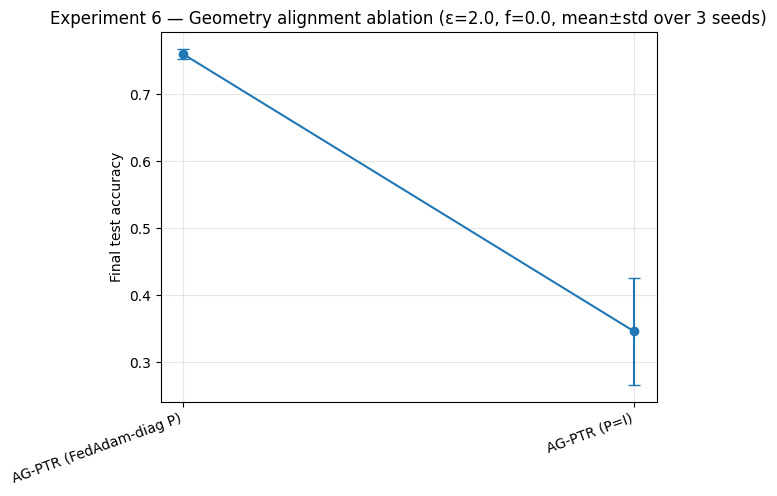

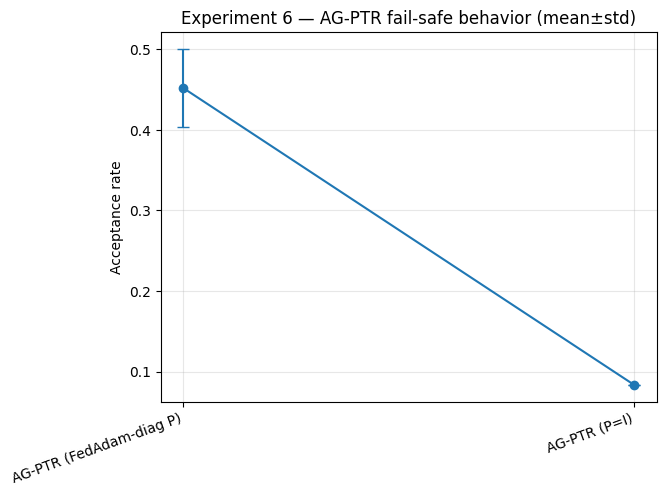

In [14]:
# Cell 15 — FULL Experiment 6: Geometry alignment ablation
# Compare AG-PTR with:
#   - P_t = I
#   - P_t = FedAdam-aligned diagonal
#
# Default: run at f=0.0 to isolate "utility loss" from DP noise.
# (You can set f=0.2 or 0.4 if you want to see behavior under Byzantine attacks too.)

seed_list = [0, 1, 2]
eps_total = 2.0
delta = 1e-5

f = 0.0   # <-- change to 0.2 / 0.4 if you want
ROUNDS = 180
LOCAL_EPOCHS = 10
BATCH_SIZE = 10

LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5

ALIE_Z = 2.0
ALIE_DIR = -1.0

# AG-PTR hyperparams
RHO = 0.79
TAU = 55
R_PUB_AVG = 8
PUB_BATCH = 20
PUB_SCALE = 0.1
PUBLIC_EPOCHS = 1

# FedAdam server params (used for BOTH variants)
ADAM_ETA = 0.1
ADAM_BETA1 = 0.9
ADAM_BETA2 = 0.99
ADAM_TAU = 1e-9
ADAM_V_INIT = 1e-6

q = CLIENTS_PER_ROUND / len(clients)

# DP sigmas for AG-PTR (same accounting as before)
sel_factor = 2.0
sigma_rel = find_sigma_rel_for_target_eps_two(eps_total, q, ROUNDS, delta, sel_factor=sel_factor)
sigma_sel = sel_factor * sigma_rel
eps_ag = epsilon_from_sigma_two(sigma_sel, sigma_rel, q, ROUNDS, delta)

print("AG-PTR sigma_sel / sigma_rel:", sigma_sel, sigma_rel, "achieved eps≈", eps_ag)
print(f"Running Exp6 at f={f} for {ROUNDS} rounds, seeds={seed_list}")
print(f"FedAdam: eta={ADAM_ETA}, beta1={ADAM_BETA1}, beta2={ADAM_BETA2}, tau={ADAM_TAU}, v_init={ADAM_V_INIT}")

rows = []

for seed in seed_list:
    acc_I, ar_I = train_ag_ptr(
        seed, eps_total, f,
        sigma_sel, sigma_rel, delta=delta,
        rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
        lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
        rho=RHO, tau=TAU,
        R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
        alie_direction=ALIE_DIR, alie_z=ALIE_Z,
        allow_zero=False,
        P_mode="identity",
        adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1, adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
    )

    acc_G, ar_G = train_ag_ptr(
        seed, eps_total, f,
        sigma_sel, sigma_rel, delta=delta,
        rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
        lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
        rho=RHO, tau=TAU,
        R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
        alie_direction=ALIE_DIR, alie_z=ALIE_Z,
        allow_zero=False,
        P_mode="fedadam_diag",
        adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1, adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
    )

    rows.append({"seed": seed, "f": f, "variant": "AG-PTR (P=I)", "acc": acc_I, "accept_rate": ar_I})
    rows.append({"seed": seed, "f": f, "variant": "AG-PTR (FedAdam-diag P)", "acc": acc_G, "accept_rate": ar_G})

df_exp6 = pd.DataFrame(rows)
df_exp6.to_csv("exp6_seedwise.csv", index=False)
print("Saved exp6_seedwise.csv")
display(df_exp6)

# summary mean ± std
summary = df_exp6.groupby("variant").agg({"acc": ["mean", "std"], "accept_rate": ["mean", "std"]}).reset_index()
summary.columns = ["variant", "acc_mean", "acc_std", "accept_mean", "accept_std"]
summary.to_csv("exp6_summary.csv", index=False)
print("Saved exp6_summary.csv")
display(summary)

# Plot: accuracy (mean±std) for the two variants
plt.figure()
plt.errorbar(summary["variant"], summary["acc_mean"], yerr=summary["acc_std"],
             marker="o", capsize=4)
plt.ylabel("Final test accuracy")
plt.title(f"Experiment 6 — Geometry alignment ablation (ε={eps_total}, f={f}, mean±std over {len(seed_list)} seeds)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.show()

# Plot: acceptance rate (mean±std)
plt.figure()
plt.errorbar(summary["variant"], summary["accept_mean"], yerr=summary["accept_std"],
             marker="o", capsize=4)
plt.ylabel("Acceptance rate")
plt.title("Experiment 6 — AG-PTR fail-safe behavior (mean±std)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.show()